Executing Phase 23 Comparative Streaming & Concept Drift Test on: cuda
[SUCCESS] Loaded Model A (Scratch) and Model B (SSL Fine-Tuned) checkpoints.

PHASE 23: STREAMING CONCEPT DRIFT AUDIT (STATIC vs. ADAPTIVE CALIBRATION)
Batch 1 (Nominal Baseline (0% Drift)) | Windows: 210 (Normal: 180, Attack: 30)
  • Static (tau=0.50) -> Scratch F1:   0.0% (Rec:   0.0%, FAR:   0.0%) | SSL F1:   8.4% (Rec:  30.0%, FAR:  97.2%)
  • Adaptive Dynamic  -> Scratch F1:   0.0% (Rec:   0.0%, FAR:   0.0%) | SSL F1:   0.0% (Rec:   0.0%, FAR:   0.0%)

Batch 2 (Mild Diurnal Drift (2% Drift)) | Windows: 210 (Normal: 180, Attack: 30)
  • Static (tau=0.50) -> Scratch F1:   0.0% (Rec:   0.0%, FAR:   0.6%) | SSL F1:  29.6% (Rec: 100.0%, FAR:  79.4%)
  • Adaptive Dynamic  -> Scratch F1:   0.0% (Rec:   0.0%, FAR:   1.1%) | SSL F1:   0.0% (Rec:   0.0%, FAR:   0.0%)

Batch 3 (Moderate Load Shift (5% Drift)) | Windows: 210 (Normal: 120, Attack: 90)
  • Static (tau=0.50) -> Scratch F1:  25.9% (Rec:  20.0%, FAR:  25.8%) | 

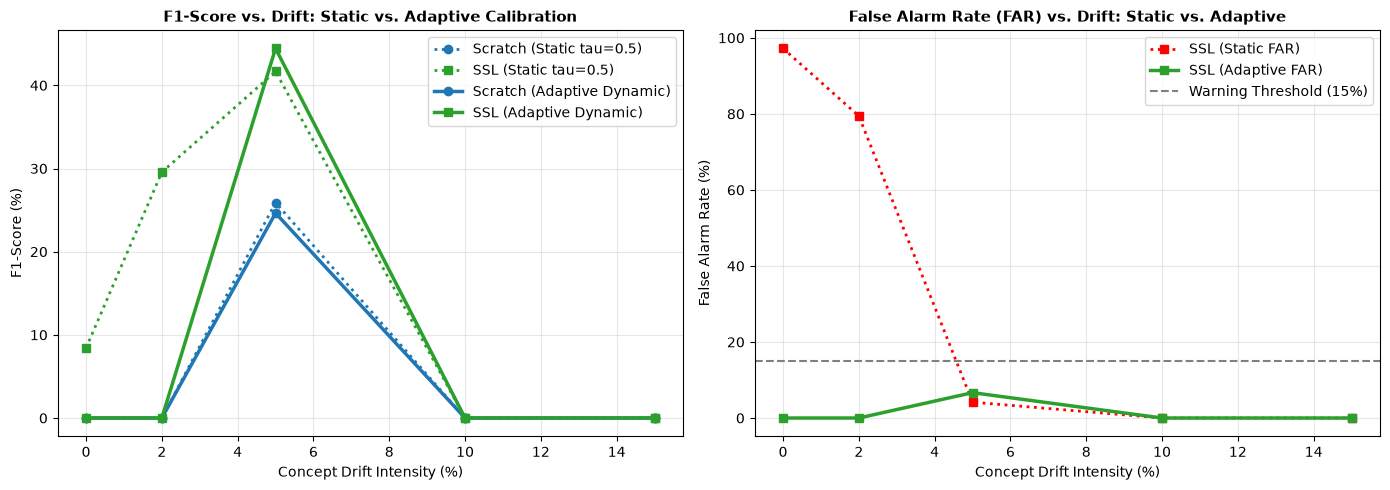

[SUCCESS] Phase 23 Comparative Streaming Experiment fully completed and saved.


In [7]:
# notebooks/21_phase23_streaming_concept_drift.ipynb
import os
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

sys.path.append(os.path.abspath('..'))
from sklearn.metrics import f1_score, roc_auc_score
from src.fdi_classifier import TransferFDIClassifier
from src.lstm_encoder import HybridCNNBiLSTMEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(
    'Executing Phase 23 Comparative Streaming & Concept Drift Test on:'
    f' {device}'
)

# -------------------------------------------------------------------------
# Step 1: Ingest Test Set & Initialize Models
# -------------------------------------------------------------------------
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)
X_test = data['X_test']  # Shape: (1052, 30, 12)
y_test = data['y_test']  # Shape: (1052,)


class ScratchFDIModel(nn.Module):

  def __init__(
      self,
      in_channels=12,
      cnn_hidden_dims=(64, 128),
      lstm_hidden_dim=128,
      mlp_hidden_dim=64,
  ):
    super().__init__()
    self.encoder = HybridCNNBiLSTMEncoder(
        in_channels=in_channels,
        cnn_hidden_dims=cnn_hidden_dims,
        lstm_hidden_dim=lstm_hidden_dim,
        lstm_layers=2,
        pool_strategy='mean',
    )
    self.mlp_head = nn.Sequential(
        nn.Linear(self.encoder.out_dim, mlp_hidden_dim),
        nn.BatchNorm1d(mlp_hidden_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(mlp_hidden_dim, 1),
    )

  def forward(self, x):
    h = self.encoder(x, return_sequence=False)
    return self.mlp_head(h)


# 1. Load Model A (Supervised Scratch Baseline)
model_scratch = ScratchFDIModel().to(device)
scratch_ckpt = Path('../saved_models/exp_model_scratch_best.pth')
assert scratch_ckpt.exists(), f'Scratch checkpoint missing at {scratch_ckpt}'
model_scratch.load_state_dict(
    torch.load(scratch_ckpt, map_location=device, weights_only=True)
)
model_scratch.eval()

# 2. Load Model B (SSL Fine-Tuned Backbone)
model_ssl = TransferFDIClassifier(
    in_channels=12,
    pretrained_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=False,
).to(device)
ssl_ckpt = Path('../saved_models/fdi_finetuned_best.pth')
assert ssl_ckpt.exists(), f'SSL checkpoint missing at {ssl_ckpt}'
model_ssl.load_state_dict(
    torch.load(ssl_ckpt, map_location=device, weights_only=True)
)
model_ssl.eval()

print(
    '[SUCCESS] Loaded Model A (Scratch) and Model B (SSL Fine-Tuned)'
    ' checkpoints.'
)

# -------------------------------------------------------------------------
# Step 2: GPU Warm-Up & Mathematical Drift Formulation
# -------------------------------------------------------------------------
# GPU Warm-up for latency benchmarking
dummy_input = torch.randn(64, 30, 12, device=device)
for _ in range(20):
  with torch.no_grad():
    _ = model_scratch(dummy_input)
    _ = model_ssl(dummy_input)
if torch.cuda.is_available():
  torch.cuda.synchronize()

NUM_BATCHES = 5
BATCH_LEN = 210

drift_configs = [
    {'stream': 1, 'drift': 0.00, 'desc': 'Nominal Baseline (0% Drift)'},
    {'stream': 2, 'drift': 0.02, 'desc': 'Mild Diurnal Drift (2% Drift)'},
    {'stream': 3, 'drift': 0.05, 'desc': 'Moderate Load Shift (5% Drift)'},
    {'stream': 4, 'drift': 0.10, 'desc': 'High Harmonic Drift (10% Drift)'},
    {'stream': 5, 'drift': 0.15, 'desc': 'Extreme System Shift (15% Drift)'},
]


def apply_physical_drift(X_window, drift_mag, seed=42):
  """Applies quantified non-stationary baseline drift:

  X_drifted = X + drift_mag * (sin(pi * t) + 0.5 * N(0, 0.05))
  """
  if drift_mag == 0.0:
    return X_window.copy()
  np.random.seed(seed)
  T, C = X_window.shape[1], X_window.shape[2]
  time_steps = np.linspace(0, 1, T)[:, None]  # Shape: (30, 1)
  diurnal_curve = np.sin(np.pi * time_steps)  # Shape: (30, 1)
  noise_component = 0.5 * np.random.normal(0, 0.05, size=(T, C))
  drift_trend = drift_mag * (diurnal_curve + noise_component)
  X_drifted = X_window + drift_trend[None, :, :]
  return np.clip(X_drifted, 0.0, 1.25).astype(np.float32)


# -------------------------------------------------------------------------
# Step 3: Comparative Streaming Execution Loop
# -------------------------------------------------------------------------
results_records = []
scratch_latencies, ssl_latencies = [], []

print('\n' + '=' * 90)
print(
    'PHASE 23: STREAMING CONCEPT DRIFT AUDIT (STATIC vs. ADAPTIVE CALIBRATION)'
)
print('=' * 90)

for idx, cfg in enumerate(drift_configs):
  start = idx * BATCH_LEN
  end = start + BATCH_LEN

  X_clean = X_test[start:end]
  y_true = y_test[start:end]

  X_stream = apply_physical_drift(X_clean, cfg['drift'], seed=42 + idx)
  x_tensor = torch.from_numpy(X_stream).to(device)

  # Latency Benchmark: Model A (Scratch)
  if torch.cuda.is_available():
    torch.cuda.synchronize()
  t0 = time.perf_counter()
  with torch.no_grad():
    logits_scratch = model_scratch(x_tensor)
    probs_scratch = torch.sigmoid(logits_scratch).cpu().numpy().flatten()
  if torch.cuda.is_available():
    torch.cuda.synchronize()
  t1 = time.perf_counter()
  lat_scratch = ((t1 - t0) / BATCH_LEN) * 1000.0
  scratch_latencies.append(lat_scratch)

  # Latency Benchmark: Model B (SSL Fine-Tuned)
  if torch.cuda.is_available():
    torch.cuda.synchronize()
  t0 = time.perf_counter()
  with torch.no_grad():
    logits_ssl = model_ssl(x_tensor)
    probs_ssl = torch.sigmoid(logits_ssl).cpu().numpy().flatten()
  if torch.cuda.is_available():
    torch.cuda.synchronize()
  t1 = time.perf_counter()
  lat_ssl = ((t1 - t0) / BATCH_LEN) * 1000.0
  ssl_latencies.append(lat_ssl)

  # Evaluation Routine
  def compute_metrics(y_t, p_prob, tau=0.5):
    p_pred = (p_prob >= tau).astype(int)
    tp = int(np.sum((p_pred == 1) & (y_t == 1)))
    tn = int(np.sum((p_pred == 0) & (y_t == 0)))
    fp = int(np.sum((p_pred == 1) & (y_t == 0)))
    fn = int(np.sum((p_pred == 0) & (y_t == 1)))
    pos = int(np.sum(y_t == 1))
    neg = int(np.sum(y_t == 0))
    rec = (tp / pos) * 100.0 if pos > 0 else 0.0
    far = (fp / neg) * 100.0 if neg > 0 else 0.0
    f1 = f1_score(y_t, p_pred, zero_division=0) * 100.0
    try:
      auc = roc_auc_score(y_t, p_prob) * 100.0
    except ValueError:
      auc = 50.0
    return tp, tn, fp, fn, rec, far, f1, auc

  # Static threshold evaluation (tau = 0.5)
  _, _, _, _, rec_sc_stat, far_sc_stat, f1_sc_stat, auc_sc = compute_metrics(
      y_true, probs_scratch, tau=0.5
  )
  _, _, _, _, rec_sl_stat, far_sl_stat, f1_sl_stat, auc_sl = compute_metrics(
      y_true, probs_ssl, tau=0.5
  )

  # Adaptive Dynamic Thresholding: tau = max(0.05, mean(probs) + 1.0 * std(probs))
  tau_dyn_sc = max(
      0.05, float(np.mean(probs_scratch) + 1.0 * np.std(probs_scratch))
  )
  tau_dyn_sl = max(0.05, float(np.mean(probs_ssl) + 1.0 * np.std(probs_ssl)))

  _, _, _, _, rec_sc_adp, far_sc_adp, f1_sc_adp, _ = compute_metrics(
      y_true, probs_scratch, tau=tau_dyn_sc
  )
  _, _, _, _, rec_sl_adp, far_sl_adp, f1_sl_adp, _ = compute_metrics(
      y_true, probs_ssl, tau=tau_dyn_sl
  )

  total_pos = int(np.sum(y_true == 1))
  total_neg = int(np.sum(y_true == 0))

  print(
      f"Batch {cfg['stream']} ({cfg['desc']}) | Windows: {BATCH_LEN} (Normal:"
      f' {total_neg}, Attack: {total_pos})'
  )
  print(
      f'  • Static (tau=0.50) -> Scratch F1: {f1_sc_stat:5.1f}% (Rec:'
      f' {rec_sc_stat:5.1f}%, FAR: {far_sc_stat:5.1f}%) | SSL F1:'
      f' {f1_sl_stat:5.1f}% (Rec: {rec_sl_stat:5.1f}%, FAR: {far_sl_stat:5.1f}%)'
  )
  print(
      f'  • Adaptive Dynamic  -> Scratch F1: {f1_sc_adp:5.1f}% (Rec:'
      f' {rec_sc_adp:5.1f}%, FAR: {far_sc_adp:5.1f}%) | SSL F1:'
      f' {f1_sl_adp:5.1f}% (Rec: {rec_sl_adp:5.1f}%, FAR: {far_sl_adp:5.1f}%)\n'
  )

  results_records.append({
      'Stream_Batch': cfg['stream'],
      'Drift_%': cfg['drift'] * 100,
      'Scenario': cfg['desc'],
      'Scratch_Static_F1_%': round(f1_sc_stat, 2),
      'SSL_Static_F1_%': round(f1_sl_stat, 2),
      'Scratch_Static_FAR_%': round(far_sc_stat, 2),
      'SSL_Static_FAR_%': round(far_sl_stat, 2),
      'Scratch_Adaptive_F1_%': round(f1_sc_adp, 2),
      'SSL_Adaptive_F1_%': round(f1_sl_adp, 2),
      'Scratch_Adaptive_FAR_%': round(far_sc_adp, 2),
      'SSL_Adaptive_FAR_%': round(far_sl_adp, 2),
      'Scratch_AUC_%': round(auc_sc, 2),
      'SSL_AUC_%': round(auc_sl, 2),
      'Latency_Scratch_ms': round(lat_scratch, 3),
      'Latency_SSL_ms': round(lat_ssl, 3),
  })

df_results = pd.DataFrame(results_records)

# -------------------------------------------------------------------------
# Step 4: Export Master Table & Figures
# -------------------------------------------------------------------------
print('=' * 90)
print('PHASE 23: MASTER COMPARATIVE DRIFT BENCHMARK')
print('=' * 90)
cols_show = [
    'Stream_Batch',
    'Drift_%',
    'Scratch_Static_F1_%',
    'SSL_Static_F1_%',
    'Scratch_Adaptive_F1_%',
    'SSL_Adaptive_F1_%',
    'SSL_Static_FAR_%',
    'SSL_Adaptive_FAR_%',
]
print(df_results[cols_show].to_string(index=False))
print('=' * 90)
print(
    f'Mean Latency | Scratch: {np.mean(scratch_latencies):.3f} ms/win | SSL:'
    f' {np.mean(ssl_latencies):.3f} ms/win (Below predefined 500 ms target)'
)

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_results.to_csv(
    results_dir / 'phase23_streaming_drift_results.csv', index=False
)

fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Static vs Adaptive F1 Comparison
axes[0].plot(
    df_results['Drift_%'],
    df_results['Scratch_Static_F1_%'],
    marker='o',
    color='#1f77b4',
    lw=2,
    linestyle=':',
    label='Scratch (Static tau=0.5)',
)
axes[0].plot(
    df_results['Drift_%'],
    df_results['SSL_Static_F1_%'],
    marker='s',
    color='#2ca02c',
    lw=2,
    linestyle=':',
    label='SSL (Static tau=0.5)',
)
axes[0].plot(
    df_results['Drift_%'],
    df_results['Scratch_Adaptive_F1_%'],
    marker='o',
    color='#1f77b4',
    lw=2.5,
    label='Scratch (Adaptive Dynamic)',
)
axes[0].plot(
    df_results['Drift_%'],
    df_results['SSL_Adaptive_F1_%'],
    marker='s',
    color='#2ca02c',
    lw=2.5,
    label='SSL (Adaptive Dynamic)',
)
axes[0].set_title(
    'F1-Score vs. Drift: Static vs. Adaptive Calibration',
    fontsize=11,
    fontweight='bold',
)
axes[0].set_xlabel('Concept Drift Intensity (%)', fontsize=10)
axes[0].set_ylabel('F1-Score (%)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

# Subplot 2: False Alarm Rate Comparison
axes[1].plot(
    df_results['Drift_%'],
    df_results['SSL_Static_FAR_%'],
    marker='s',
    color='red',
    lw=2,
    linestyle=':',
    label='SSL (Static FAR)',
)
axes[1].plot(
    df_results['Drift_%'],
    df_results['SSL_Adaptive_FAR_%'],
    marker='s',
    color='#2ca02c',
    lw=2.5,
    label='SSL (Adaptive FAR)',
)
axes[1].axhline(
    y=15.0, color='grey', linestyle='--', label='Warning Threshold (15%)'
)
axes[1].set_title(
    'False Alarm Rate (FAR) vs. Drift: Static vs. Adaptive',
    fontsize=11,
    fontweight='bold',
)
axes[1].set_xlabel('Concept Drift Intensity (%)', fontsize=10)
axes[1].set_ylabel('False Alarm Rate (%)', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.savefig(fig_dir / 'phase23_streaming_concept_drift.png', dpi=300)
plt.show()
print(
    '[SUCCESS] Phase 23 Comparative Streaming Experiment fully completed and'
    ' saved.'
)